# FNN拟合一元函数

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
import torch
import torch.nn as nn
# import torch.nn.functional as F
import numpy as np
import pandas as pd

import time
# import scipy.io as io
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams['font.sans-serif']=['Times New Roman'] #设置默认字体
plt.rcParams['axes.unicode_minus']=False

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('running on: %s'%(device))


running on: cuda


## 构建FNN网络

In [2]:
## ----构建FNN网络----
class FNN(nn.Module):
    def __init__(self, layers, actn = 'tanh'):
        super().__init__()
        L = len(layers)


        self.linear = nn.ModuleList([nn.Linear(layers[l-1], layers[l]) for l in range(1, L)])

        # 激活函数
        if actn == 'relu':
            actn = nn.ReLU()
        elif actn == 'tanh':
            actn = nn.Tanh()
        elif actn == 'sigmoid':
            actn = nn.Sigmoid()
        self.activation = actn

    def forward(self, inputs):
        x = inputs
        for linear in self.linear[:-1]:
            x = self.activation(linear(x))
        x = self.linear[-1](x)
        return x


## 目标函数与数据集

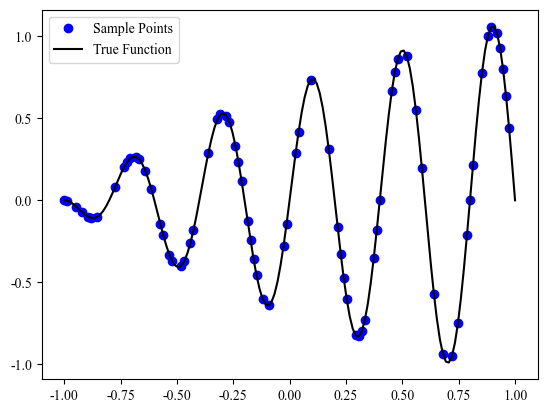

In [ ]:


# 目标函数
def target_func(x):
    return  np.sin(5*np.pi*x) * np.log(x+2)

# 生成数据
def generate_data(num_train=75): # 样本点数
    num_test = 151 # 全集与样本点数
    x = np.linspace(-1, 1, num_test).reshape((-1, 1))
    y = target_func(x)
    idx = np.random.choice(num_test, num_train,  replace=False)

    #训练点数
    x_train, y_train = x[idx], y[idx]
    return x_train, y_train, x, y

# 训练点数
num_train = 75
# 数据集
x_train, y_train, x_ref, y_ref = generate_data(num_train)

plt.figure()
plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')
plt.legend()
plt.show()

## 模型训练

In [4]:
## ----模型训练---
'''默认参数
layers=[1, 50, 50, 1], 
actn='tanh', 
epochs=30000
'''

# 训练模型
def train_model(x_train, y_train, layers=[1, 50, 50, 1], actn='tanh', epochs=30000):
    # 网络模型
    model = FNN(layers, actn)
    model = model.to(device)
    # print(model.state_dict()['linear.2.weight'].shape)

    x_train, y_train = torch.tensor(x_train, dtype=torch.float32), \
        torch.tensor(y_train, dtype=torch.float32)
    x_train, y_train = x_train.to(device), y_train.to(device)


    opt = torch.optim.Adam(model.parameters(), lr=1.0e-3)
    loss_fn = nn.MSELoss()

    loss_history = []
    partial_loss_history = []

    start_time=time.time()

    for epoch in range(0,epochs+1):
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        opt.zero_grad() #梯度清零
        loss.backward()
        opt.step()
        loss_history.append(loss.item())

        if epoch%1000 == 0:
            # print('Steps: %d, loss: %.3e'%(epoch, loss.item()))
            partial_loss_history.append(loss.item())

    end_time = time.time()

    # 训练时间
    train_time = end_time - start_time
    # 每轮损失值
    loss_history = np.array(loss_history).reshape(-1,1)
    return model.cpu(), loss_history, partial_loss_history, train_time





In [5]:
default_epochs = train_model.__defaults__[2]
default_n = np.array([i for i in range(0,default_epochs+1,1000)])
default_n

array([    0,  1000,  2000,  3000,  4000,  5000,  6000,  7000,  8000,
        9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000,
       18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000,
       27000, 28000, 29000, 30000])

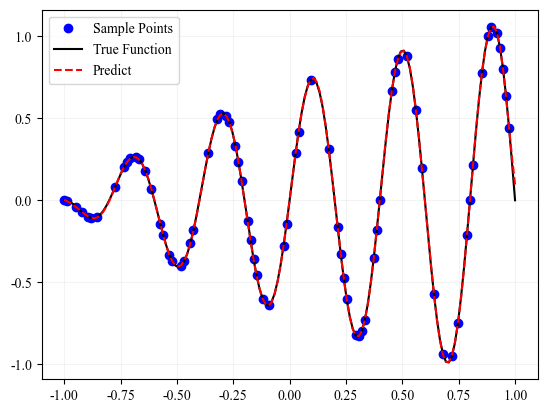

In [6]:
## ----初始测验----
#  网络结构层数与深度
layers = [1] + [50]*2 + [1]
# 激活函数
actn = 'tanh'
# 训练轮次
epochs = 30000


model, loss, partial_loss, train_time= train_model(x_train, y_train, layers, actn, epochs)

x_ref = torch.tensor(x_ref, dtype=torch.float32)
y_test = model(x_ref)

plt.figure()

plt.plot(x_train, y_train, 'bo',label='Sample Points')
plt.plot(x_ref, y_ref, 'k-',label='True Function')

plt.plot(x_ref, y_test.detach().numpy(), 'r--',label="Predict")

plt.legend()
plt.grid(ls='-', alpha=0.15)
plt.show()

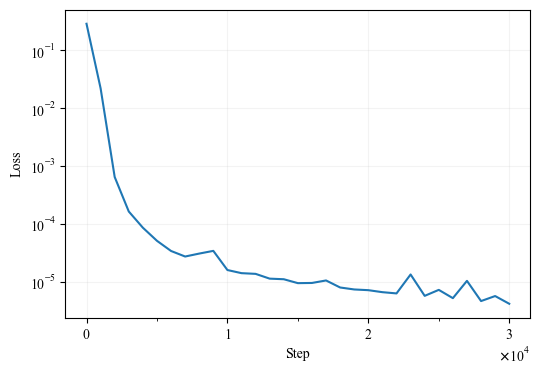

In [7]:
# 损失函数
partial_n = np.array([i for i in range(0,epochs+1,1000)])

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(partial_n, partial_loss)


ax.set_yscale('log')
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(ticker.NullLocator())

ax.xaxis.set_major_locator(ticker.MultipleLocator(10000))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5000))

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((4,4))
ax.xaxis.set_major_formatter(formatter)

plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(ls='-', alpha=0.15)
plt.show()

## 模型评估与可视化函数

In [8]:
## 模型评估

def evaluate(model):

    x_test=np.linspace(-1,1,151).reshape((-1,1))
    y_true=target_func(x_test)

    x_test_tensor=torch.tensor(x_test, dtype=torch.float32)

    with torch.no_grad():
        y_pred=model.cpu()(x_test_tensor)

    mse=mean_squared_error(y_true,y_pred)
    mae=mean_absolute_error(y_true,y_pred)

    return x_test, y_true, y_pred, mse, mae
 
test = evaluate(model)
print(dict(zip(['MSE','MAE'],test[3:])))

{'MSE': 7.671053032123257e-05, 'MAE': 0.0030602423417516625}


In [ ]:
## ----可视化----

# 真实-预测曲线
def plot_curve(x_true,y_true,y_pred,title):
    plt.figure(figsize=(6,4))
    plt.plot(x_true,y_true,'k-',label="True Function")
    plt.plot(x_true,y_pred,'r--',label="Predict")
    plt.title(title)
    plt.grid(ls='-', alpha=0.15)
    plt.legend()
    plt.show()


# 损失函数可视化
def plot_loss(loss_dict, title):
    fig, ax = plt.subplots(figsize=(6,4))
    for key, loss in loss_dict.items():
        ax.plot(default_n, loss, label=key)

    ax.set_yscale('log')
    ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax.yaxis.set_minor_locator(ticker.NullLocator())

    ax.xaxis.set_major_locator(ticker.MultipleLocator(10000))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(5000))

    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((4,4))
    ax.xaxis.set_major_formatter(formatter)

    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.grid(ls='-', alpha=0.15)
    plt.title(title)
    plt.legend()
    plt.show()


# 训练时间图
def plot_train_time(dict, time_list, xlabel):
    pro = [str(s) for s in dict]

    plt.figure(figsize=(6,4))

    colors = plt.cm.Blues(np.linspace(0.4,0.9,len(pro)))
    bars = plt.bar(pro,time_list, width=0.6, color=colors, 
                   edgecolor='black', linewidth=1)

    plt.xlabel(xlabel)
    plt.ylabel("Training Time (s)")
    plt.ylim(bottom=min(time_list)-5) 

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, 
                 height + 0.02, f"{height:.3f}", ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## 问题1：训练点数影响

当前训练点数： 15


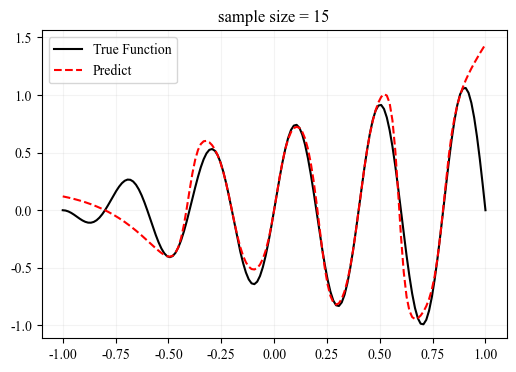

当前训练点数： 35


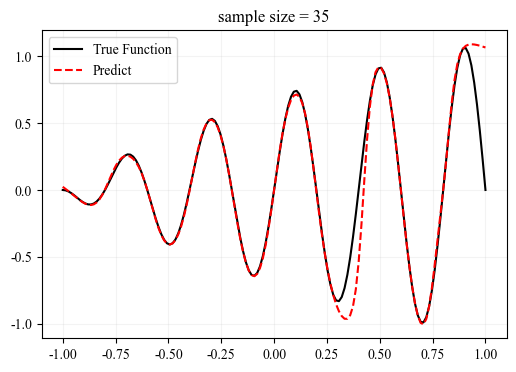

当前训练点数： 55


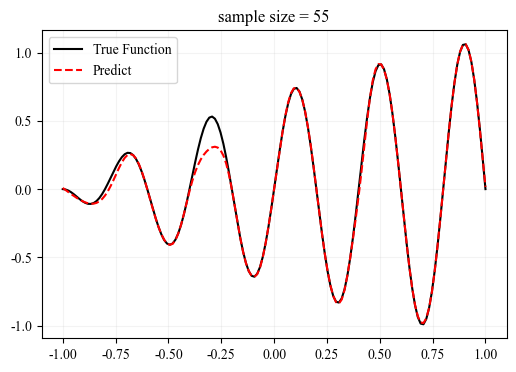

当前训练点数： 75


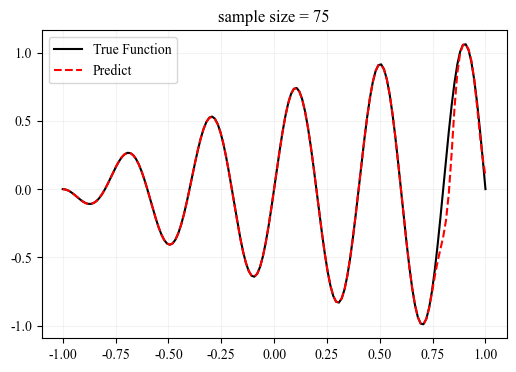

当前训练点数： 100


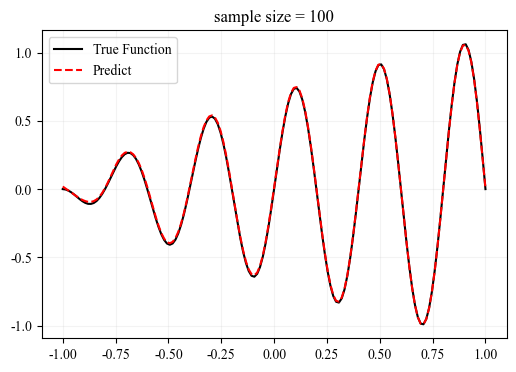

In [10]:
## ----训练点数影响----
# 训练点数
sample_sizes = [15, 35, 55, 75, 100]

# 训练点数-MSE-MAE对
results_q1 = []
# 训练点数-损失值对
loss_dict_q1 = {}

for n in sample_sizes:
    print('当前训练点数：',n)
    # 模型训练
    x_train_q1, y_train_q1, x_ref_q1, y_ref_q1 = generate_data(n)
    model_q1, loss_q1, partial_loss_q1, train_time_q1= train_model(x_train_q1, y_train_q1)

    # 模型评估
    x_test_q1, y_true_q1, y_pred_q1, mse_q1, mae_q1 = evaluate(model_q1)
    results_q1.append([n, mse_q1, mae_q1])

    loss_dict_q1[str(n)+' samples'] = partial_loss_q1
    
    plot_curve(x_test_q1, y_true_q1, y_pred_q1,f"sample size = {n}")



   Sample_Sizes       MSE       MAE
0            15  0.053194  0.125071
1            35  0.027340  0.055559
2            55  0.002416  0.019600
3            75  0.005069  0.017001
4           100  0.000074  0.007525


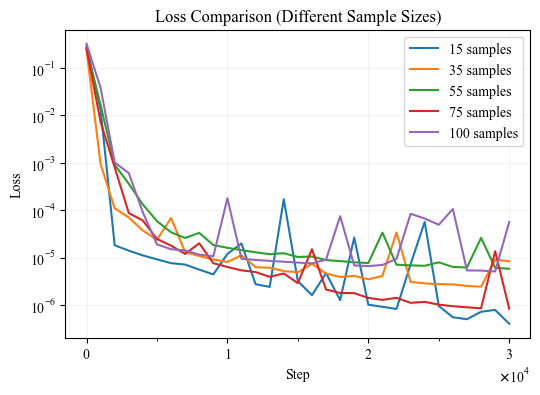

In [11]:
# 比较MSE/MAE/损失曲线
df_q1=pd.DataFrame(results_q1,columns=['Sample_Sizes','MSE','MAE'])
print(df_q1)


plot_loss(loss_dict_q1, title='Loss Comparison (Different Sample Sizes)')

## 问题2：网络结构（层数与深度）影响

当前网络结构： [1, 20, 20, 1]
MSE: 4.77995802663968e-05 MAE: 0.0034317594249366904 Train_time: 31.75520634651184


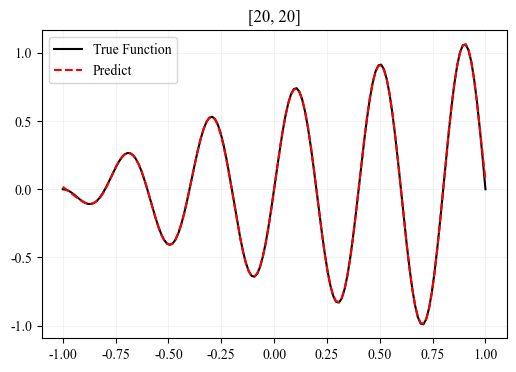

当前网络结构： [1, 20, 20, 20, 1]
MSE: 1.6151533601480342e-05 MAE: 0.0023732749216304077 Train_time: 36.87631583213806


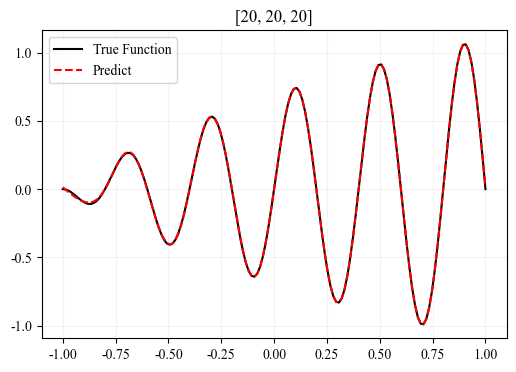

当前网络结构： [1, 50, 50, 1]
MSE: 2.931212363694e-05 MAE: 0.003428429600853573 Train_time: 31.96116328239441


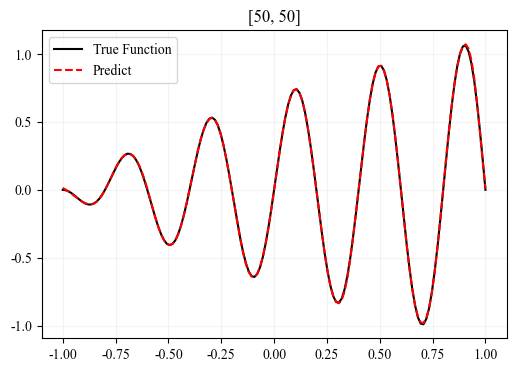

当前网络结构： [1, 50, 50, 50, 1]
MSE: 2.0869754158569672e-05 MAE: 0.0037034871381488184 Train_time: 44.991158962249756


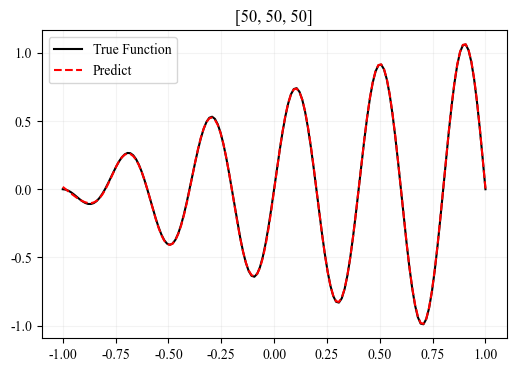

当前网络结构： [1, 50, 50, 50, 50, 1]
MSE: 9.365882933433533e-05 MAE: 0.006366627221910868 Train_time: 71.51539349555969


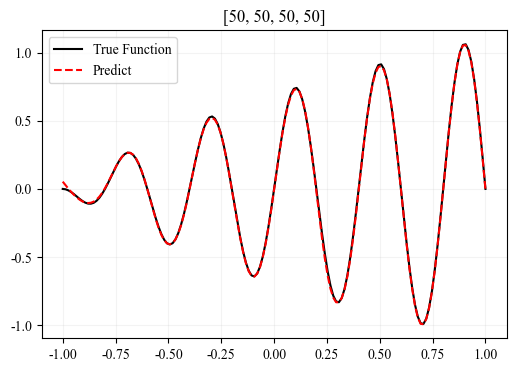

当前网络结构： [1, 100, 100, 1]
MSE: 1.5665335735482885e-05 MAE: 0.0018416941556798543 Train_time: 38.254005670547485


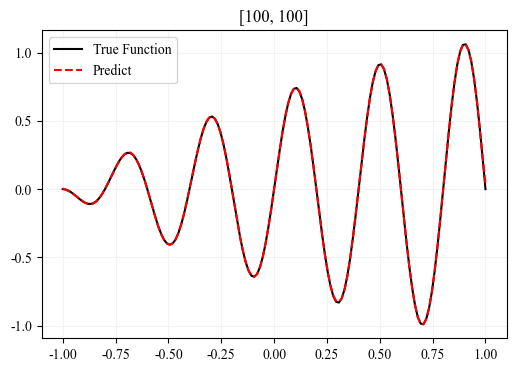

In [12]:
## ----网络结构影响----
# 网络结构
hide_layers = [[20,20], [20,20,20], [50,50], [50,50,50],
               [50,50,50,50],[100,100]]

# 网络结构-MSE-MAE-训练时间对
results_q2 = []
# 网络结构-损失值对
loss_dict_q2 = {}
# 网络结构-训练时间对
time_list_q2 = []

for s in hide_layers:
    layers_q2 = [1] + s +[1]
    print('当前网络结构：',layers_q2)
    # 模型训练
    x_train_q2, y_train_q2, x_ref_q2, y_ref_q2 = generate_data()
    model_q2, loss_q2, partial_loss_q2, train_time_q2 = train_model(x_train_q2, y_train_q2, layers=layers_q2)

    # 模型评估
    x_test_q2, y_true_q2, y_pred_q2, mse_q2, mae_q2 = evaluate(model_q2)
    
    print('MSE:',mse_q2,'MAE:',mae_q2,'Train_time:',train_time_q2)

    results_q2.append([s, mse_q2, mae_q2, train_time_q2])
    loss_dict_q2[str(s)] = partial_loss_q2
    time_list_q2.append(train_time_q2)

    plot_curve(x_test_q2, y_true_q2, y_pred_q2, str(s))

        Hide_Layers       MSE       MAE  Train_time
0          [20, 20]  0.000048  0.003432   31.755206
1      [20, 20, 20]  0.000016  0.002373   36.876316
2          [50, 50]  0.000029  0.003428   31.961163
3      [50, 50, 50]  0.000021  0.003703   44.991159
4  [50, 50, 50, 50]  0.000094  0.006367   71.515393
5        [100, 100]  0.000016  0.001842   38.254006


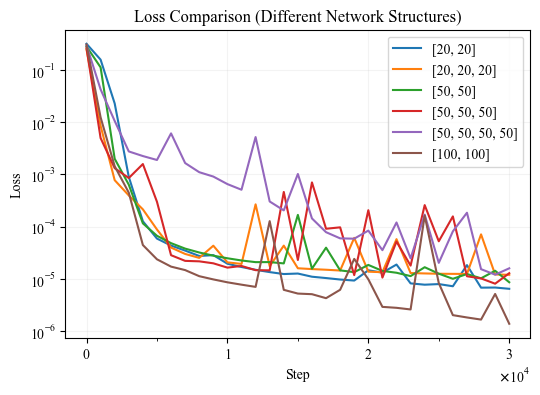

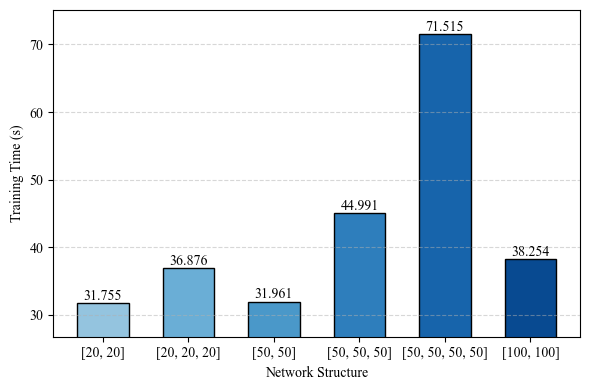

In [13]:
# 比较MSE/MAE/损失曲线/训练时间
df_q2=pd.DataFrame(results_q2,columns=['Hide_Layers','MSE','MAE','Train_time'])
print(df_q2)


plot_loss(loss_dict_q2, title='Loss Comparison (Different Network Structures)')

plot_train_time(hide_layers, time_list_q2, xlabel="Network Structure")

## 问题3：激活函数影响

当前激活函数： relu
Structure: [100, 100] MSE: 0.002411565253608412 MAE: 0.03920356955798466 Train_Time: 44.873950719833374


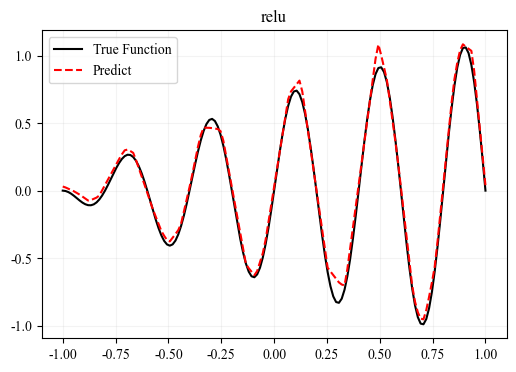

当前激活函数： tanh
Structure: [100, 100] MSE: 2.497168053467922e-05 MAE: 0.0022806545914303466 Train_Time: 37.7976553440094


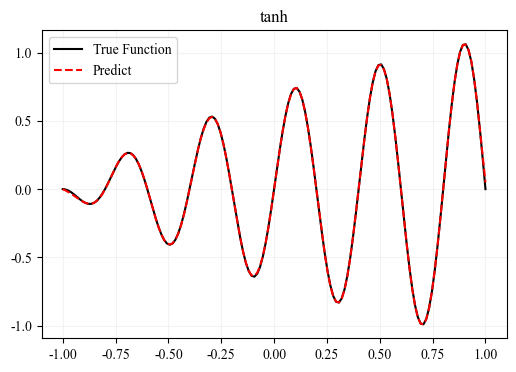

当前激活函数： sigmoid
Structure: [100, 100] MSE: 9.111884001399938e-05 MAE: 0.005753399436633242 Train_Time: 37.532845973968506


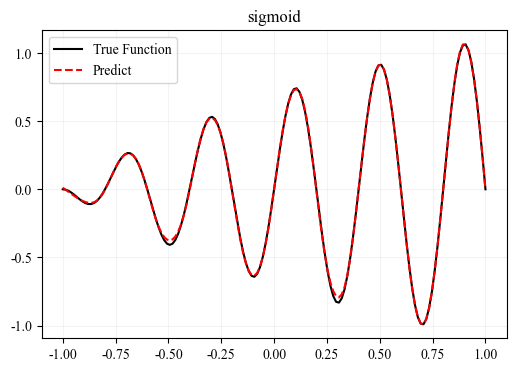

In [ ]:
## ----激活函数影响----
# 激活函数
activations = ['relu', 'tanh', 'sigmoid']

# 激活函数-MSE-MAE对
results_q3 = []
# 激活函数-损失值对
loss_dict_q3 = {}
# 激活函数-训练时间对
time_list_q3 = []

for act in activations:
    print('当前激活函数：',act)
    # 模型训练
    x_train_q3, y_train_q3, x_ref_q3, y_ref_q3 = generate_data()
    model_q3, loss_q3, partial_loss_q3, train_time_q3 = train_model(x_train_q3, y_train_q3, actn = act)

    #模型评估
    x_test_q3, y_true_q3, y_pred_q3, mse_q3, mae_q3 = evaluate(model_q3)

    print('Structure:', act, "MSE:", mse_q3, "MAE:", mae_q3, 'Train_Time:', train_time_q3)

    results_q3.append([act, mse_q3, mae_q3])
    loss_dict_q3[act] = partial_loss_q3
    time_list_q3.append(train_time_q3)

    plot_curve(x_test_q3, y_true_q3, y_pred_q3, act)

  Activation       MSE       MAE
0       relu  0.002412  0.039204
1       tanh  0.000025  0.002281
2    sigmoid  0.000091  0.005753


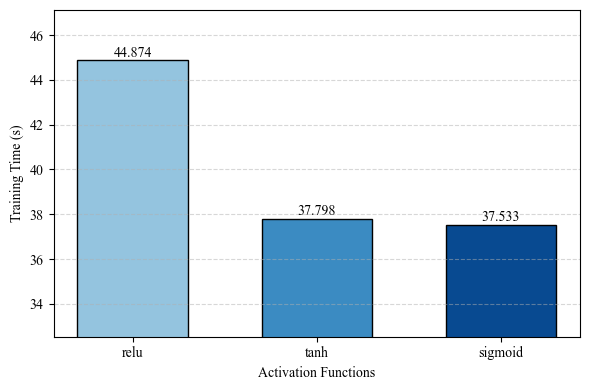

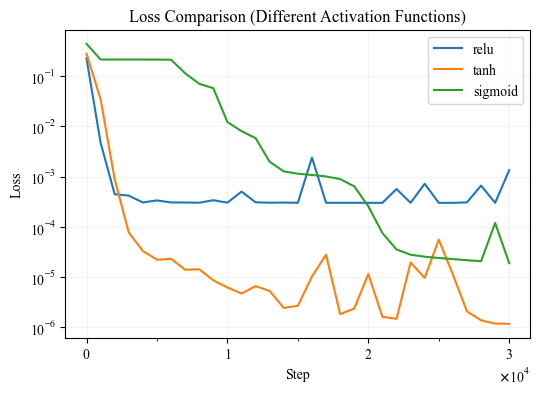

In [15]:
# 比较MSE/MAE/损失曲线/训练时间
df_q3=pd.DataFrame(results_q3,columns=['Activation','MSE','MAE'])
print(df_q3)

plot_train_time(activations, time_list_q3,xlabel="Activation Functions")

plot_loss(loss_dict_q3, title='Loss Comparison (Different Activation Functions)')